In [1]:
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
Egr1_hyper_DHMR <- read.csv(paste0(indir,"/03-EGR1_DHMR_Hyper_motif_enrichment_analysis_subclass.csv"))

In [3]:
head(Egr1_hyper_DHMR);dim(Egr1_hyper_DHMR)

,motif,count_subclass,total_subclass_minus_count,count_background,total_background_minus_count,oddsratio,p_value,adjusted_p_value,subclass
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,EGR1,40,60,1434,3162,1.4700139,6.445366e-02,6.445366e-02,ACB-BST-FS D1 Gaba
2,EGR1,9871,29843,1434,3162,0.7293423,4.995900e-20,4.995900e-20,Astro-TE NN
3,EGR1,20820,57730,1434,3162,0.7952284,6.021103e-12,6.021103e-12,CA1-ProS Glut
4,EGR1,11043,25552,1434,3162,0.9529605,1.575448e-01,1.575448e-01,CA3 Glut
5,EGR1,362,481,1434,3162,1.6594960,5.664383e-11,5.664383e-11,CLA-EPd-CTX Car3 Glut
6,EGR1,17121,42399,1434,3162,0.8904022,5.051353e-04,5.051353e-04,DG Glut


[1] 25  9

In [4]:
library(ggplot2)

In [5]:
Egr1_hyper_DHMR <- Egr1_hyper_DHMR %>%
  mutate(percentage = count_subclass / (count_subclass + total_subclass_minus_count))

Egr1_hyper_DHMR

motif,count_subclass,total_subclass_minus_count,count_background,total_background_minus_count,oddsratio,p_value,adjusted_p_value,subclass,percentage
<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
EGR1,40,60,1434,3162,1.4700139,6.445366e-02,6.445366e-02,ACB-BST-FS D1 Gaba,0.4000000
EGR1,9871,29843,1434,3162,0.7293423,4.995900e-20,4.995900e-20,Astro-TE NN,0.2485521
EGR1,20820,57730,1434,3162,0.7952284,6.021103e-12,6.021103e-12,CA1-ProS Glut,0.2650541
EGR1,11043,25552,1434,3162,0.9529605,1.575448e-01,1.575448e-01,CA3 Glut,0.3017625
EGR1,362,481,1434,3162,1.6594960,5.664383e-11,5.664383e-11,CLA-EPd-CTX Car3 Glut,0.4294187
EGR1,17121,42399,1434,3162,0.8904022,5.051353e-04,5.051353e-04,DG Glut,0.2876512
EGR1,17,18,1434,3162,2.0825198,4.211497e-02,4.211497e-02,IT AON-TT-DP Glut,0.4857143
EGR1,36839,98469,1434,3162,0.8249374,4.670275e-09,4.670275e-09,L2/3 IT CTX Glut,0.2722603
EGR1,2308,4542,1434,3162,1.1204730,5.365215e-03,5.365215e-03,L2/3 IT RSP Glut,0.3369343


In [ ]:
file_paths <- c(
  paste0(indir,"/03-EGR1_DHMR_Hyper_motif_enrichment_analysis_subclass.csv")
)

In [7]:
groups <- c("DHMR_Hyper") # , "DHMR_Hypo", "DMR_Hyper", "DMR_Hypo"

In [8]:
unique(Egr1_hyper_DHMR$subclass)

[1] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "CA1-ProS Glut"        
 [4] "CA3 Glut"              "CLA-EPd-CTX Car3 Glut" "DG Glut"              
 [7] "IT AON-TT-DP Glut"     "L2/3 IT CTX Glut"      "L2/3 IT RSP Glut"     
[10] "L4/5 IT CTX Glut"      "L5 ET CTX Glut"        "L5 IT CTX Glut"       
[13] "L5 NP CTX Glut"        "L6 CT CTX Glut"        "Lamp5 Gaba"           
[16] "Microglia NN"          "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"     
[19] "OB-out Frmd7 Gaba"     "OEC NN"                "OPC NN"               
[22] "Oligo NN"              "Pvalb Gaba"            "STR D1 Sema5a Gaba"   
[25] "STR D2 Gaba"

In [9]:
subclass_order <- unlist(strsplit("L2/3 IT CTX Glut
L4/5 IT CTX Glut
L5 IT CTX Glut
IT AON-TT-DP Glut
L2/3 IT RSP Glut
L5 ET CTX Glut
CA1-ProS Glut
CA3 Glut
CLA-EPd-CTX Car3 Glut
L5 NP CTX Glut
L6 CT CTX Glut
DG Glut
OB Eomes Ms4a15 Glut
OB-in Frmd7 Gaba
OB-out Frmd7 Gaba
Sncg Gaba
Lamp5 Gaba
Pvalb Gaba
STR D1 Gaba
STR D2 Gaba
STR D1 Sema5a Gaba
ACB-BST-FS D1 Gaba
Astro-TE NN
Oligo NN
OPC NN
OEC NN
Microglia NN","\n"))

subclass_order

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "IT AON-TT-DP Glut"     "L2/3 IT RSP Glut"      "L5 ET CTX Glut"       
 [7] "CA1-ProS Glut"         "CA3 Glut"              "CLA-EPd-CTX Car3 Glut"
[10] "L5 NP CTX Glut"        "L6 CT CTX Glut"        "DG Glut"              
[13] "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"      "OB-out Frmd7 Gaba"    
[16] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[19] "STR D1 Gaba"           "STR D2 Gaba"           "STR D1 Sema5a Gaba"   
[22] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[25] "OPC NN"                "OEC NN"                "Microglia NN"

In [10]:
length(subclass_order)

[1] 27

In [11]:
table(unique(Egr1_hyper_DHMR$subclass) %in% subclass_order)
table(subclass_order %in% unique(Egr1_hyper_DHMR$subclass))


TRUE 
  25 


FALSE  TRUE 
    2    25 

In [48]:
subclass_order[!subclass_order %in% unique(Egr1_hyper_DHMR$subclass)]

[1] "Sncg Gaba"   "STR D1 Gaba"

In [8]:
# subclass_order <- unlist(strsplit("L2/3 IT CTX Glut
# L4/5 IT CTX Glut
# L5 IT CTX Glut
# IT AON-TT-DP Glut
# L2/3 IT RSP Glut
# L5 ET CTX Glut
# CA1-ProS Glut
# CA3 Glut
# CLA-EPd-CTX Car3 Glut
# L5 NP CTX Glut
# L6 CT CTX Glut
# DG Glut
# OB Eomes Ms4a15 Glut
# OB-in Frmd7 Gaba
# OB-out Frmd7 Gaba
# OB-STR-CTX Inh IMN
# Sncg Gaba
# Lamp5 Gaba
# Pvalb Gaba
# STR D1 Gaba
# STR D2 Gaba
# STR D1 Sema5a Gaba
# ACB-BST-FS D1 Gaba
# Oligo NN
# OPC NN
# OEC NN
# Microglia NN","\n"))

# subclass_order

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "IT AON-TT-DP Glut"     "L2/3 IT RSP Glut"      "L5 ET CTX Glut"       
 [7] "CA1-ProS Glut"         "CA3 Glut"              "CLA-EPd-CTX Car3 Glut"
[10] "L5 NP CTX Glut"        "L6 CT CTX Glut"        "DG Glut"              
[13] "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"      "OB-out Frmd7 Gaba"    
[16] "OB-STR-CTX Inh IMN"    "Sncg Gaba"             "Lamp5 Gaba"           
[19] "Pvalb Gaba"            "STR D1 Gaba"           "STR D2 Gaba"          
[22] "STR D1 Sema5a Gaba"    "ACB-BST-FS D1 Gaba"    "Oligo NN"             
[25] "OPC NN"                "OEC NN"                "Microglia NN"

In [12]:
data_list <- lapply(seq_along(file_paths), function(i) {
  data <- read.csv(file_paths[i])
  min_nonzero_pval <- min(data$adjusted_p_value[data$adjusted_p_value > 0], na.rm = TRUE)
  data <- data %>%
    mutate(
      adjusted_p_value = ifelse(adjusted_p_value == 0, min_nonzero_pval, adjusted_p_value),
      group = groups[i]
    )
  
  return(data)
})

data_list

motif,count_subclass,total_subclass_minus_count,count_background,total_background_minus_count,oddsratio,p_value,adjusted_p_value,subclass,group
<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
EGR1,40,60,1434,3162,1.4700139,6.445366e-02,6.445366e-02,ACB-BST-FS D1 Gaba,DHMR_Hyper
EGR1,9871,29843,1434,3162,0.7293423,4.995900e-20,4.995900e-20,Astro-TE NN,DHMR_Hyper
EGR1,20820,57730,1434,3162,0.7952284,6.021103e-12,6.021103e-12,CA1-ProS Glut,DHMR_Hyper
EGR1,11043,25552,1434,3162,0.9529605,1.575448e-01,1.575448e-01,CA3 Glut,DHMR_Hyper
EGR1,362,481,1434,3162,1.6594960,5.664383e-11,5.664383e-11,CLA-EPd-CTX Car3 Glut,DHMR_Hyper
EGR1,17121,42399,1434,3162,0.8904022,5.051353e-04,5.051353e-04,DG Glut,DHMR_Hyper
EGR1,17,18,1434,3162,2.0825198,4.211497e-02,4.211497e-02,IT AON-TT-DP Glut,DHMR_Hyper
EGR1,36839,98469,1434,3162,0.8249374,4.670275e-09,4.670275e-09,L2/3 IT CTX Glut,DHMR_Hyper
EGR1,2308,4542,1434,3162,1.1204730,5.365215e-03,5.365215e-03,L2/3 IT RSP Glut,DHMR_Hyper


In [13]:
Egr1_combined <- bind_rows(data_list)
Egr1_combined

motif,count_subclass,total_subclass_minus_count,count_background,total_background_minus_count,oddsratio,p_value,adjusted_p_value,subclass,group
<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
EGR1,40,60,1434,3162,1.4700139,6.445366e-02,6.445366e-02,ACB-BST-FS D1 Gaba,DHMR_Hyper
EGR1,9871,29843,1434,3162,0.7293423,4.995900e-20,4.995900e-20,Astro-TE NN,DHMR_Hyper
EGR1,20820,57730,1434,3162,0.7952284,6.021103e-12,6.021103e-12,CA1-ProS Glut,DHMR_Hyper
EGR1,11043,25552,1434,3162,0.9529605,1.575448e-01,1.575448e-01,CA3 Glut,DHMR_Hyper
EGR1,362,481,1434,3162,1.6594960,5.664383e-11,5.664383e-11,CLA-EPd-CTX Car3 Glut,DHMR_Hyper
EGR1,17121,42399,1434,3162,0.8904022,5.051353e-04,5.051353e-04,DG Glut,DHMR_Hyper
EGR1,17,18,1434,3162,2.0825198,4.211497e-02,4.211497e-02,IT AON-TT-DP Glut,DHMR_Hyper
EGR1,36839,98469,1434,3162,0.8249374,4.670275e-09,4.670275e-09,L2/3 IT CTX Glut,DHMR_Hyper
EGR1,2308,4542,1434,3162,1.1204730,5.365215e-03,5.365215e-03,L2/3 IT RSP Glut,DHMR_Hyper


In [14]:
Egr1_combined <- Egr1_combined %>%
  mutate(
    percentage = count_subclass / (count_subclass + total_subclass_minus_count),
    subclass = factor(subclass, levels = subclass_order)
  )

In [15]:
head(Egr1_combined);dim(Egr1_combined)

,motif,count_subclass,total_subclass_minus_count,count_background,total_background_minus_count,oddsratio,p_value,adjusted_p_value,subclass,group,percentage
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<dbl>
1,EGR1,40,60,1434,3162,1.4700139,6.445366e-02,6.445366e-02,ACB-BST-FS D1 Gaba,DHMR_Hyper,0.4000000
2,EGR1,9871,29843,1434,3162,0.7293423,4.995900e-20,4.995900e-20,Astro-TE NN,DHMR_Hyper,0.2485521
3,EGR1,20820,57730,1434,3162,0.7952284,6.021103e-12,6.021103e-12,CA1-ProS Glut,DHMR_Hyper,0.2650541
4,EGR1,11043,25552,1434,3162,0.9529605,1.575448e-01,1.575448e-01,CA3 Glut,DHMR_Hyper,0.3017625
5,EGR1,362,481,1434,3162,1.6594960,5.664383e-11,5.664383e-11,CLA-EPd-CTX Car3 Glut,DHMR_Hyper,0.4294187
6,EGR1,17121,42399,1434,3162,0.8904022,5.051353e-04,5.051353e-04,DG Glut,DHMR_Hyper,0.2876512


[1] 25 11

In [16]:
library(ggplot2)
library(dplyr)

In [17]:
Egr1_combined <- Egr1_combined %>%
  mutate(size = -log10(adjusted_p_value))

In [18]:
head(Egr1_combined);dim(Egr1_combined)

,motif,count_subclass,total_subclass_minus_count,count_background,total_background_minus_count,oddsratio,p_value,adjusted_p_value,subclass,group,percentage,size
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<dbl>,<dbl>
1,EGR1,40,60,1434,3162,1.4700139,6.445366e-02,6.445366e-02,ACB-BST-FS D1 Gaba,DHMR_Hyper,0.4000000,1.1907524
2,EGR1,9871,29843,1434,3162,0.7293423,4.995900e-20,4.995900e-20,Astro-TE NN,DHMR_Hyper,0.2485521,19.3013863
3,EGR1,20820,57730,1434,3162,0.7952284,6.021103e-12,6.021103e-12,CA1-ProS Glut,DHMR_Hyper,0.2650541,11.2203239
4,EGR1,11043,25552,1434,3162,0.9529605,1.575448e-01,1.575448e-01,CA3 Glut,DHMR_Hyper,0.3017625,0.8025959
5,EGR1,362,481,1434,3162,1.6594960,5.664383e-11,5.664383e-11,CLA-EPd-CTX Car3 Glut,DHMR_Hyper,0.4294187,10.2468474
6,EGR1,17121,42399,1434,3162,0.8904022,5.051353e-04,5.051353e-04,DG Glut,DHMR_Hyper,0.2876512,3.2965923


[1] 25 12

In [19]:
library(patchwork)

Warning message:
“package ‘patchwork’ was built under R version 4.3.2”


In [ ]:
aging_DHMR_state_final <- read.csv(paste0(indir,"/01-dhmr_hyper_hypo_DHMR_include_region.csv"))

In [21]:
dim(aging_DHMR_state_final);colnames(aging_DHMR_state_final)

[1] 25  6

[1] "X"                     "Subclass"              "Specific_Hyper_Region"
[4] "Specific_Hyper_Count"  "Specific_Hypo_Region"  "Specific_Hypo_Count"

In [22]:
aging_DHMR_state_final_filter <- aging_DHMR_state_final[,c("Subclass","Specific_Hyper_Count","Specific_Hypo_Count")]

In [23]:
aging_DHMR_state_final_filter

Subclass,Specific_Hyper_Count,Specific_Hypo_Count
<chr>,<int>,<int>
ACB-BST-FS D1 Gaba,100,3
Astro-TE NN,39714,494
CA1-ProS Glut,78550,1345
CA3 Glut,36595,498
CLA-EPd-CTX Car3 Glut,843,6
DG Glut,59520,2771
IT AON-TT-DP Glut,35,8
L2/3 IT CTX Glut,135308,788
L2/3 IT RSP Glut,6850,162


In [24]:
colnames(aging_DHMR_state_final_filter) <- c("subclass","DHMR_Hyper","DHMR_Hypo")

In [25]:
aging_DHMR_state_final_filter

subclass,DHMR_Hyper,DHMR_Hypo
<chr>,<int>,<int>
ACB-BST-FS D1 Gaba,100,3
Astro-TE NN,39714,494
CA1-ProS Glut,78550,1345
CA3 Glut,36595,498
CLA-EPd-CTX Car3 Glut,843,6
DG Glut,59520,2771
IT AON-TT-DP Glut,35,8
L2/3 IT CTX Glut,135308,788
L2/3 IT RSP Glut,6850,162


In [ ]:
aging_DMR_state_final <- read.csv(paste0(indir,"/01-dmr_hyper_hypo_DMR_include_region.csv"))

In [27]:
dim(aging_DMR_state_final);colnames(aging_DMR_state_final)

[1] 23  6

[1] "X"                     "Subclass"              "Specific_Hyper_Region"
[4] "Specific_Hyper_Count"  "Specific_Hypo_Region"  "Specific_Hypo_Count"

In [28]:
aging_DMR_state_final_filter <- aging_DMR_state_final[,c("Subclass","Specific_Hyper_Count","Specific_Hypo_Count")]

In [29]:
colnames(aging_DMR_state_final_filter) <- c("subclass","DMR_Hyper","DMR_Hypo")

In [30]:
aging_DMR_state_final_filter

subclass,DMR_Hyper,DMR_Hypo
<chr>,<int>,<int>
ACB-BST-FS D1 Gaba,6526,632
Astro-TE NN,43045,2092
CA1-ProS Glut,47982,3785
CA3 Glut,8192,2304
CLA-EPd-CTX Car3 Glut,0,6
DG Glut,26969,5649
IT AON-TT-DP Glut,7003,561
L2/3 IT CTX Glut,6238,2763
L2/3 IT RSP Glut,13442,1051


In [31]:
aging_all_state_final_filter <- merge(aging_DHMR_state_final_filter,aging_DMR_state_final_filter,by = "subclass")

In [32]:
aging_all_state_final_filter

subclass,DHMR_Hyper,DHMR_Hypo,DMR_Hyper,DMR_Hypo
<chr>,<int>,<int>,<int>,<int>
ACB-BST-FS D1 Gaba,100,3,6526,632
Astro-TE NN,39714,494,43045,2092
CA1-ProS Glut,78550,1345,47982,3785
CA3 Glut,36595,498,8192,2304
CLA-EPd-CTX Car3 Glut,843,6,0,6
DG Glut,59520,2771,26969,5649
IT AON-TT-DP Glut,35,8,7003,561
L2/3 IT CTX Glut,135308,788,6238,2763
L2/3 IT RSP Glut,6850,162,13442,1051


In [33]:
library(dplyr)
library(tidyr)

In [34]:
aging_long <- aging_DHMR_state_final_filter %>%
  pivot_longer(cols = starts_with("DHMR"), 
               names_to = "group", 
               values_to = "Number")

In [35]:
head(aging_long);dim(aging_long);aging_long

subclass,group,Number
<chr>,<chr>,<int>
ACB-BST-FS D1 Gaba,DHMR_Hyper,100
ACB-BST-FS D1 Gaba,DHMR_Hypo,3
Astro-TE NN,DHMR_Hyper,39714
Astro-TE NN,DHMR_Hypo,494
CA1-ProS Glut,DHMR_Hyper,78550
CA1-ProS Glut,DHMR_Hypo,1345


[1] 50  3

subclass,group,Number
<chr>,<chr>,<int>
ACB-BST-FS D1 Gaba,DHMR_Hyper,100
ACB-BST-FS D1 Gaba,DHMR_Hypo,3
Astro-TE NN,DHMR_Hyper,39714
Astro-TE NN,DHMR_Hypo,494
CA1-ProS Glut,DHMR_Hyper,78550
CA1-ProS Glut,DHMR_Hypo,1345
CA3 Glut,DHMR_Hyper,36595
CA3 Glut,DHMR_Hypo,498
CLA-EPd-CTX Car3 Glut,DHMR_Hyper,843


In [31]:
# aging_long <- aging_all_state_final_filter %>%
#   pivot_longer(cols = starts_with("DHMR") | starts_with("DMR"), 
#                names_to = "group", 
#                values_to = "Number")

In [32]:
# head(aging_long);dim(aging_long);aging_long

subclass,group,Number
<chr>,<chr>,<int>
ACB-BST-FS D1 Gaba,DHMR_Hyper,1268
ACB-BST-FS D1 Gaba,DHMR_Hypo,220
ACB-BST-FS D1 Gaba,DMR_Hyper,1849
ACB-BST-FS D1 Gaba,DMR_Hypo,118
CA1-ProS Glut,DHMR_Hyper,9588
CA1-ProS Glut,DHMR_Hypo,234


[1] 108   3

subclass,group,Number
<chr>,<chr>,<int>
ACB-BST-FS D1 Gaba,DHMR_Hyper,1268
ACB-BST-FS D1 Gaba,DHMR_Hypo,220
ACB-BST-FS D1 Gaba,DMR_Hyper,1849
ACB-BST-FS D1 Gaba,DMR_Hypo,118
CA1-ProS Glut,DHMR_Hyper,9588
CA1-ProS Glut,DHMR_Hypo,234
CA1-ProS Glut,DMR_Hyper,20079
CA1-ProS Glut,DMR_Hypo,1030
CA3 Glut,DHMR_Hyper,6824


In [36]:
Egr1_combined <- Egr1_combined %>%
  left_join(aging_long, by = c("subclass", "group"))

In [37]:
head(Egr1_combined);dim(Egr1_combined)

,motif,count_subclass,total_subclass_minus_count,count_background,total_background_minus_count,oddsratio,p_value,adjusted_p_value,subclass,group,percentage,size,Number
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<int>
1,EGR1,40,60,1434,3162,1.4700139,6.445366e-02,6.445366e-02,ACB-BST-FS D1 Gaba,DHMR_Hyper,0.4000000,1.1907524,100
2,EGR1,9871,29843,1434,3162,0.7293423,4.995900e-20,4.995900e-20,Astro-TE NN,DHMR_Hyper,0.2485521,19.3013863,39714
3,EGR1,20820,57730,1434,3162,0.7952284,6.021103e-12,6.021103e-12,CA1-ProS Glut,DHMR_Hyper,0.2650541,11.2203239,78550
4,EGR1,11043,25552,1434,3162,0.9529605,1.575448e-01,1.575448e-01,CA3 Glut,DHMR_Hyper,0.3017625,0.8025959,36595
5,EGR1,362,481,1434,3162,1.6594960,5.664383e-11,5.664383e-11,CLA-EPd-CTX Car3 Glut,DHMR_Hyper,0.4294187,10.2468474,843
6,EGR1,17121,42399,1434,3162,0.8904022,5.051353e-04,5.051353e-04,DG Glut,DHMR_Hyper,0.2876512,3.2965923,59520


[1] 25 13

In [38]:
levels(Egr1_combined$subclass)

NULL

In [39]:
Egr1_combined$subclass <- factor(Egr1_combined$subclass, levels = subclass_order)

In [40]:
levels(Egr1_combined$subclass)

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "IT AON-TT-DP Glut"     "L2/3 IT RSP Glut"      "L5 ET CTX Glut"       
 [7] "CA1-ProS Glut"         "CA3 Glut"              "CLA-EPd-CTX Car3 Glut"
[10] "L5 NP CTX Glut"        "L6 CT CTX Glut"        "DG Glut"              
[13] "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"      "OB-out Frmd7 Gaba"    
[16] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[19] "STR D1 Gaba"           "STR D2 Gaba"           "STR D1 Sema5a Gaba"   
[22] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[25] "OPC NN"                "OEC NN"                "Microglia NN"

In [41]:
library(RColorBrewer)

In [42]:
color_palette <- rev(brewer.pal(20, "RdYlBu"))

Warning message in brewer.pal(20, "RdYlBu"):
“n too large, allowed maximum for palette RdYlBu is 11
Returning the palette you asked for with that many colors
”


In [43]:
plots_new2 <- Egr1_combined %>%
  split(.$group) %>%
  lapply(function(df) {
    ggplot(df, aes(x = size, y = subclass)) +
      geom_point(aes(size = Number, fill = oddsratio), shape = 21) + 
      geom_segment(aes(x = 0, xend = size, y = subclass, yend = subclass), 
                   linewidth = 0.5, color = "grey") +
#       geom_vline(xintercept = -log10(0.01), linetype = "dashed", color = "red", size = 0.5) +
      geom_vline(xintercept = -log10(0.05), linetype = "dashed", color = "blue", size = 0.5) +
      scale_fill_gradientn(colors = color_palette) +
      theme_classic() +
      theme(
        axis.text.y = element_text(size = 10, color = "black"),
        axis.text.x = element_text(size = 10, color = "black"),
        plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
        legend.position = "right"
      ) +
      labs(
        title = unique(df$group),
        x = "-log10(Adjusted P-value)",
        y = "Subclass",
        size = "Number",
        fill = "Odds Ratio"
      )
  })


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


$DHMR_Hyper


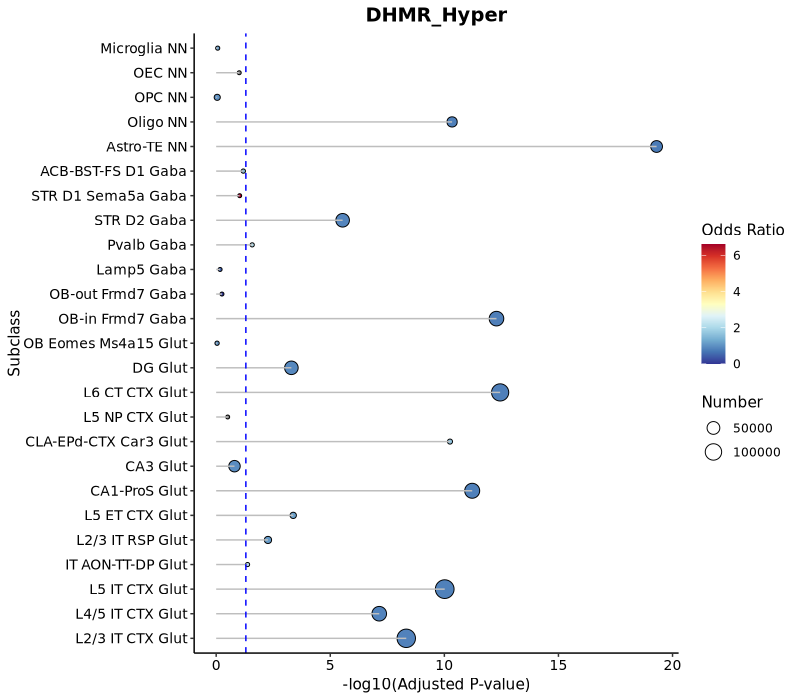

In [44]:
options(repr.plot.width = 8, repr.plot.height = 7, repr.plot.res = 100)
plots_new2

In [45]:
plots_new2 <- Egr1_combined %>%
  split(.$group) %>%
  lapply(function(df) {
    ggplot(df, aes(x = size, y = subclass)) +
      geom_point(aes(size = Number, fill = percentage), shape = 21) + 
      geom_segment(aes(x = 0, xend = size, y = subclass, yend = subclass), 
                   linewidth = 0.5, color = "grey") +
#       geom_vline(xintercept = -log10(0.01), linetype = "dashed", color = "red", size = 0.5) +
      geom_vline(xintercept = -log10(0.05), linetype = "dashed", color = "blue", size = 0.5) +
      scale_fill_gradientn(
        colors = color_palette,
        limits = c(0, 0.5)
#         oob = scales::squish
      ) +
      theme_classic() +
      theme(
        axis.text.y = element_text(size = 10, color = "black"),
        axis.text.x = element_text(size = 10, color = "black"),
        plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
        legend.position = "right"
      ) +
      labs(
        title = unique(df$group),
        x = "-log10(Adjusted P-value)",
        y = "Subclass",
        size = "Number",
        fill = "% with EGR1-binding-motif"
      )
  })

$DHMR_Hyper


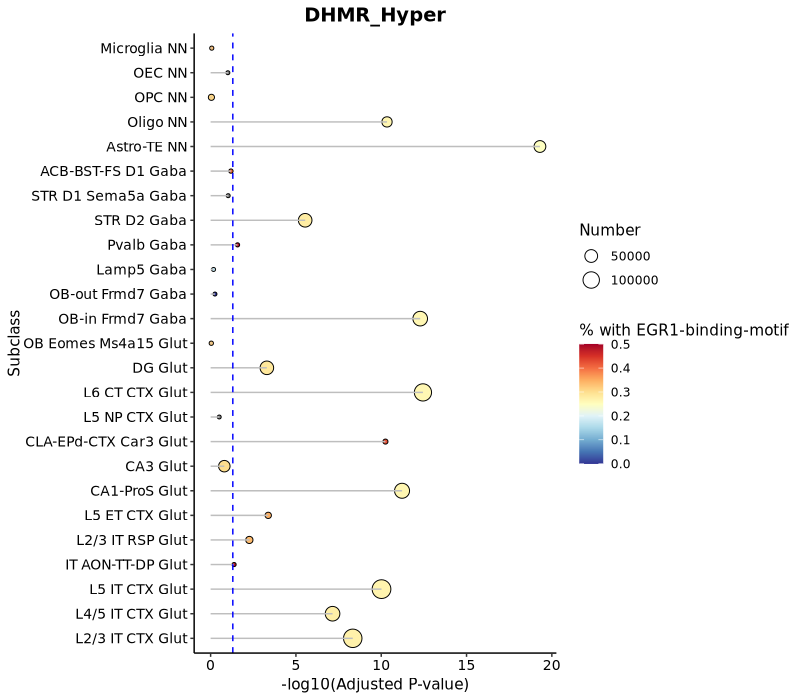

In [46]:
options(repr.plot.width = 8, repr.plot.height = 7, repr.plot.res = 100)
plots_new2

In [ ]:
pdf("../../output/03-aging/04-motif_enrichment/04-Lollipop_chart_for_EGR1_motif_enrichment_subclass_including_number_final.pdf",width = 8,height = 7)
plots_new2
dev.off()

$DHMR_Hyper


png 
  2

In [40]:
# plots_new2 <- Egr1_combined %>%
#   split(.$group) %>%
#   lapply(function(df) {
#     ggplot(df, aes(x = size, y = subclass)) +
#       geom_point(aes(size = Number, fill = oddsratio), shape = 21) + 
#       geom_segment(aes(x = 0, xend = size, y = subclass, yend = subclass), 
#                    linewidth = 0.5, color = "grey") +
# #       geom_vline(xintercept = -log10(0.01), linetype = "dashed", color = "red", size = 0.5) +
#       geom_vline(xintercept = -log10(0.05), linetype = "dashed", color = "blue", size = 0.5) +
#       scale_fill_gradientn(colors = color_palette) +
#       theme_classic() +
#       theme(
#         axis.text.y = element_text(size = 10, color = "black"),
#         axis.text.x = element_text(size = 10, color = "black"),
#         plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
#         legend.position = "right"
#       ) +
#       labs(
#         title = unique(df$group),
#         x = "-log10(Adjusted P-value)",
#         y = "Subclass",
#         size = "Number",
#         fill = "Odds Ratio"
#       )
#   })


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


In [41]:
# combined_plot_new2 <- wrap_plots(plots_new2, ncol = 2)

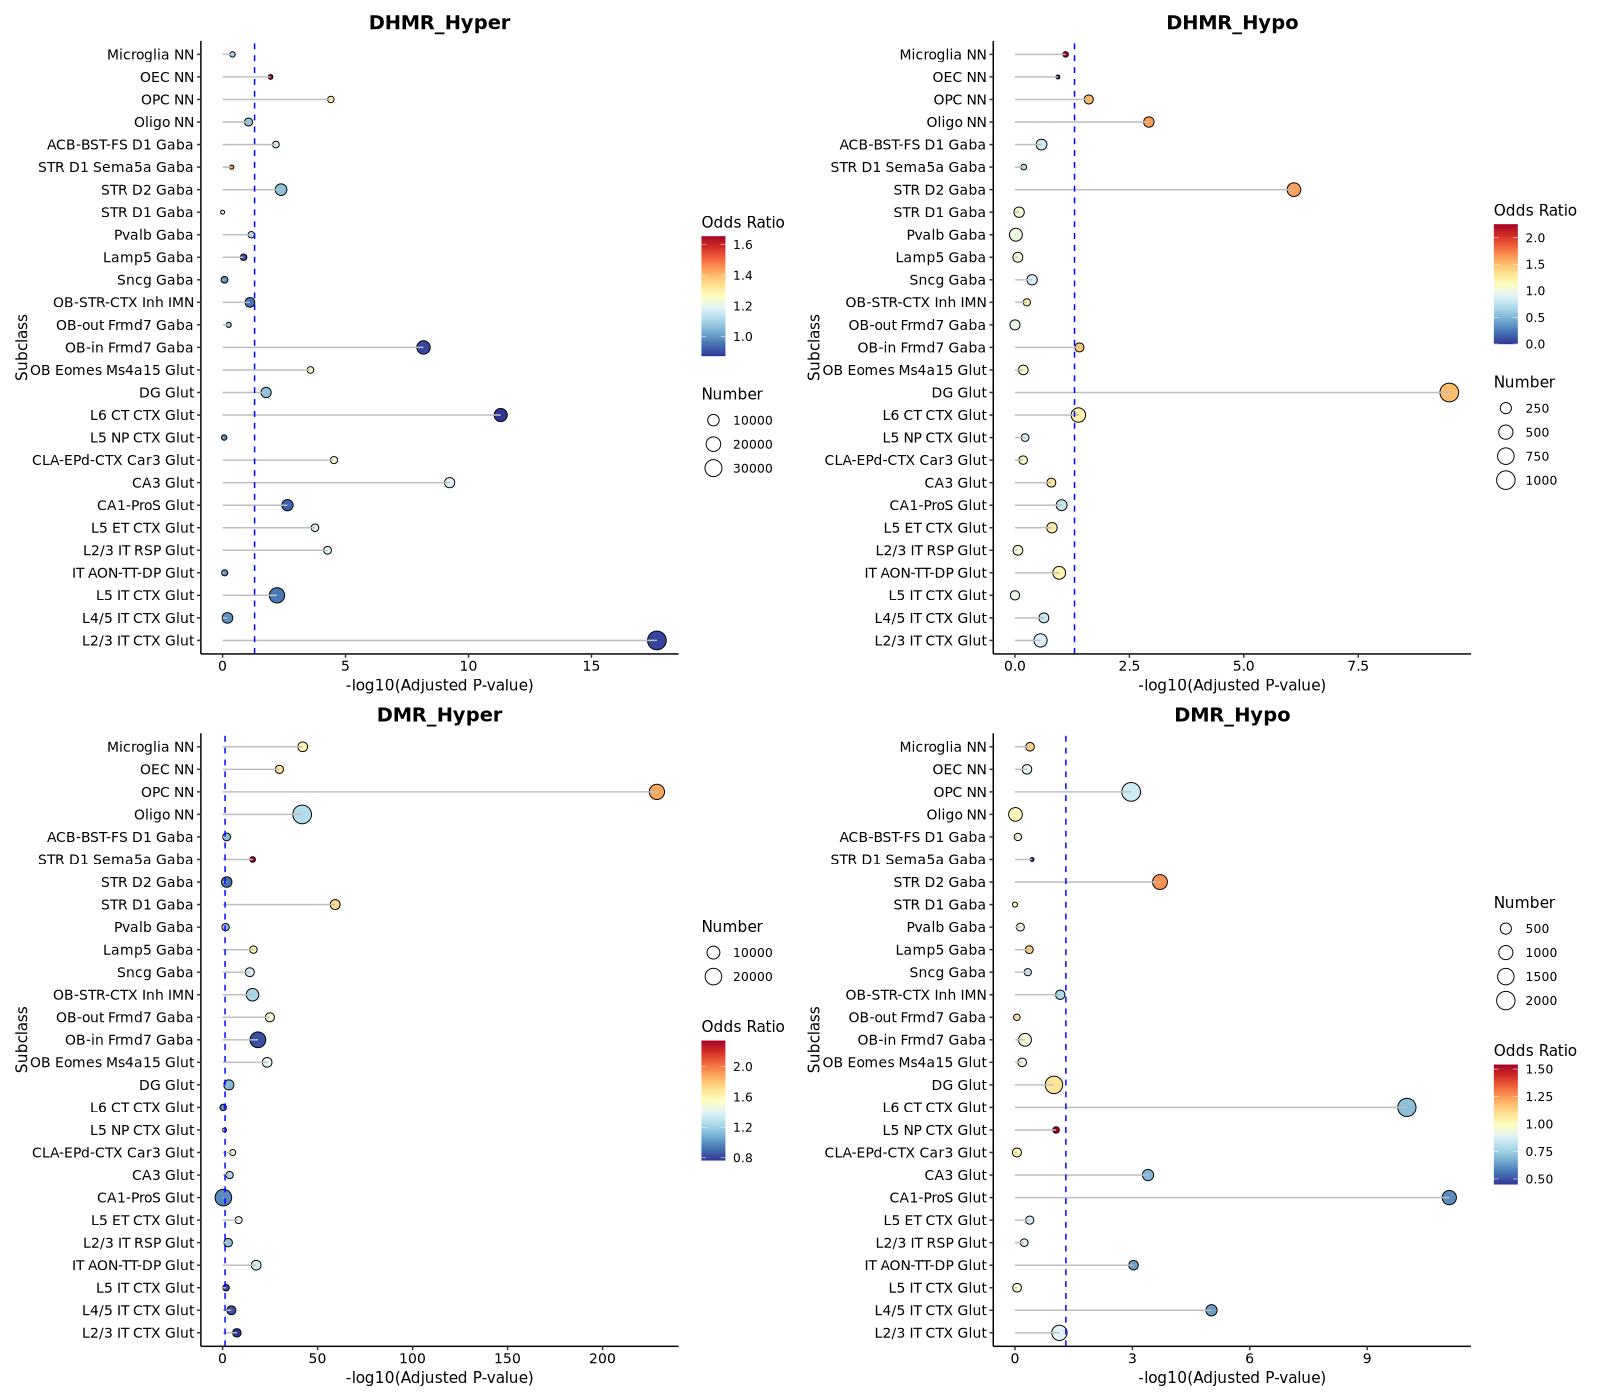

In [42]:
# options(repr.plot.width = 16, repr.plot.height = 14, repr.plot.res = 100)
# combined_plot_new2

In [43]:
# plots_new2 <- Egr1_combined %>%
#   split(.$group) %>%
#   lapply(function(df) {
#     ggplot(df, aes(x = size, y = subclass)) +
#       geom_point(aes(size = Number, fill = percentage), shape = 21) + 
#       geom_segment(aes(x = 0, xend = size, y = subclass, yend = subclass), 
#                    linewidth = 0.5, color = "grey") +
# #       geom_vline(xintercept = -log10(0.01), linetype = "dashed", color = "red", size = 0.5) +
#       geom_vline(xintercept = -log10(0.05), linetype = "dashed", color = "blue", size = 0.5) +
#       scale_fill_gradientn(
#         colors = color_palette,
#         limits = c(0, 0.5)
# #         oob = scales::squish
#       ) +
#       theme_classic() +
#       theme(
#         axis.text.y = element_text(size = 10, color = "black"),
#         axis.text.x = element_text(size = 10, color = "black"),
#         plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
#         legend.position = "right"
#       ) +
#       labs(
#         title = unique(df$group),
#         x = "-log10(Adjusted P-value)",
#         y = "Subclass",
#         size = "Number",
#         fill = "% with EGR1-binding-motif"
#       )
#   })

In [44]:
# combined_plot_new2 <- wrap_plots(plots_new2, ncol = 2)

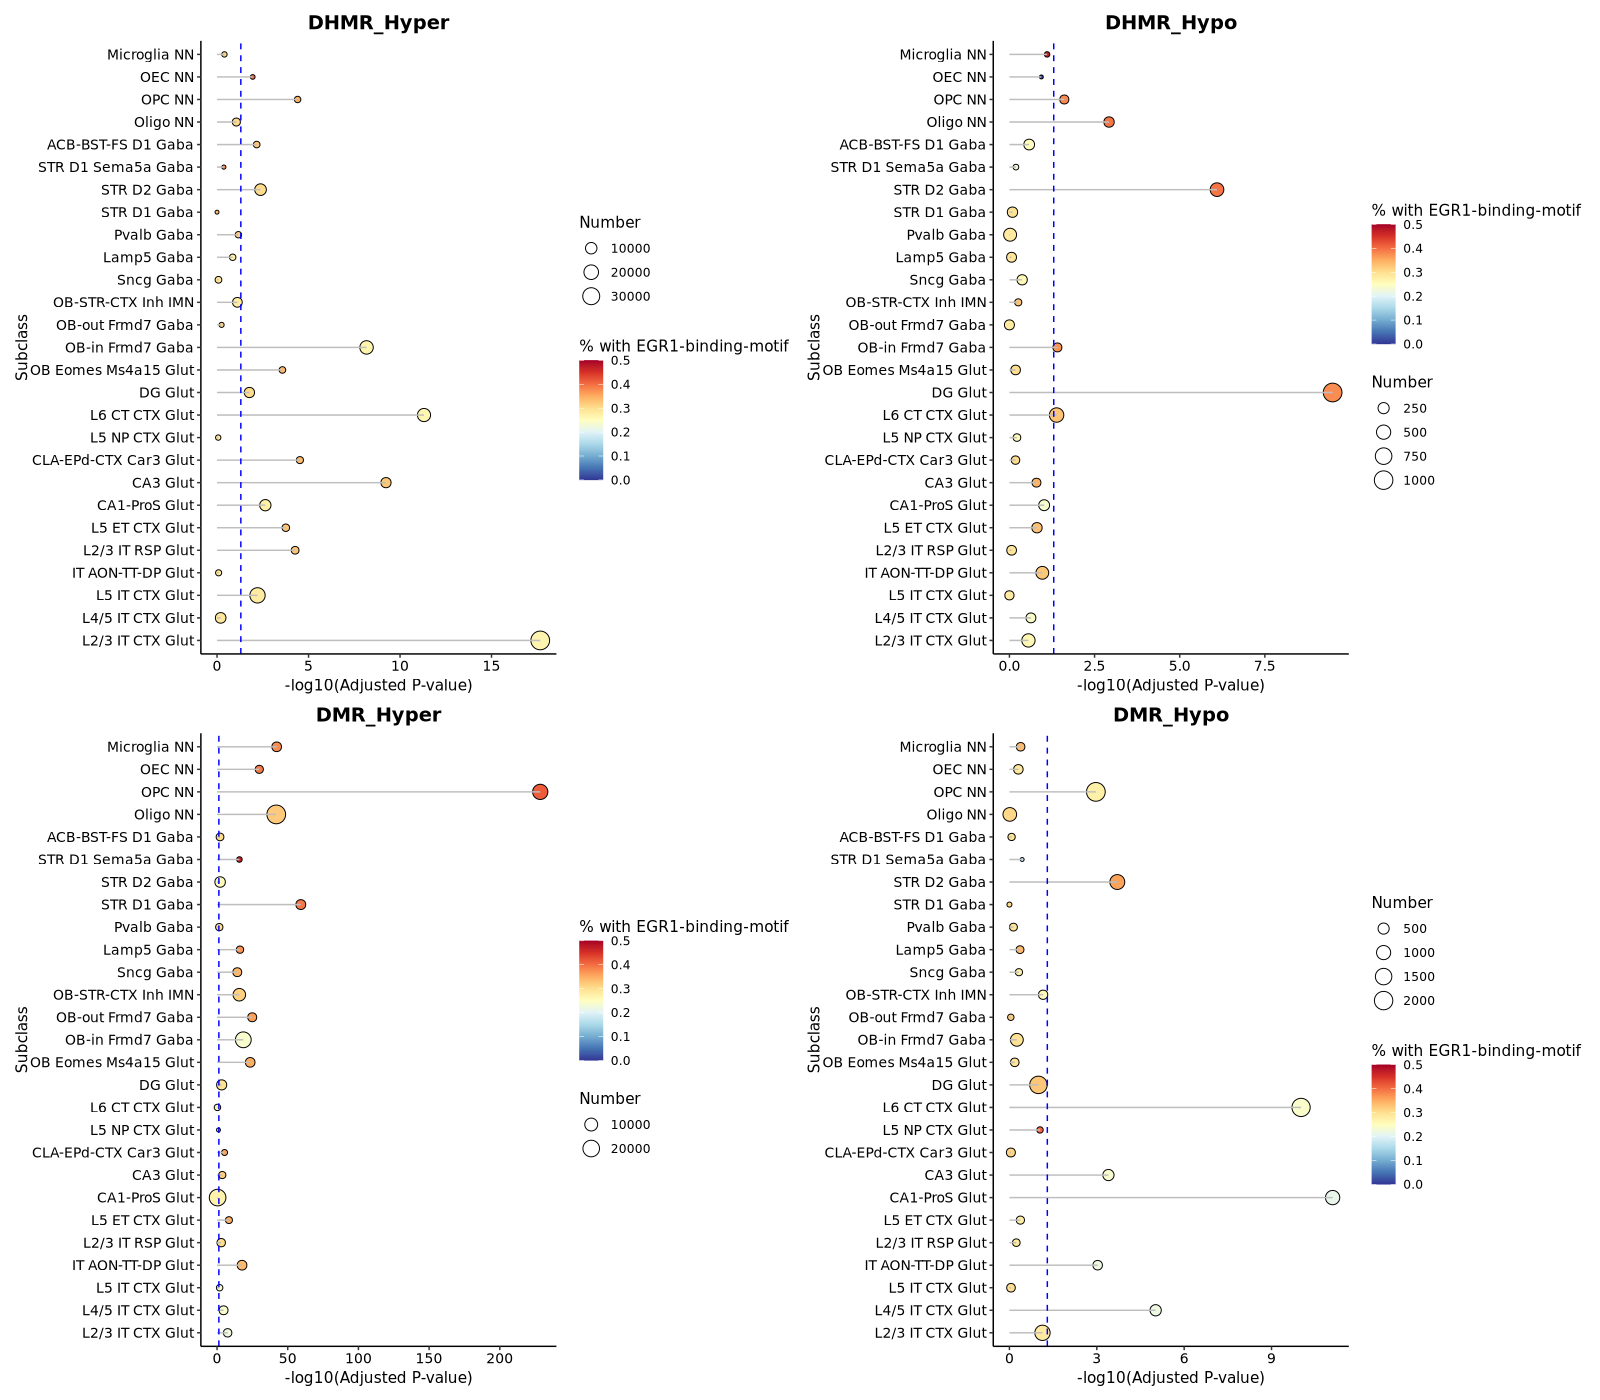

In [45]:
# options(repr.plot.width = 16, repr.plot.height = 14, repr.plot.res = 100)
# combined_plot_new2

In [46]:
# pdf("../output/04-Lollipop_chart_for_EGR1_motif_enrichment_subclass_including_number_final.pdf",width = 16,height = 14)
# combined_plot_new2
# dev.off()

png 
  2